In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/NLP_Part3', exist_ok=True)
SAVE_DIR = '/content/drive/MyDrive/NLP_Part3'
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
from google.colab import files
uploaded = files.upload()  # upload your zip here

Saving 6. News Category Dataset.zip to 6. News Category Dataset.zip


In [4]:
import zipfile

with zipfile.ZipFile('6. News Category Dataset.zip', 'r') as z:
    z.extractall('/content/data')

import os
# Find the csv file
for root, dirs, files_list in os.walk('/content/data'):
    for f in files_list:
        print(os.path.join(root, f))

/content/data/6. News Category Dataset/news_category.csv
/content/data/6. News Category Dataset/6. Description News Category Dataset.txt


In [5]:
# Install extra libraries not in Colab by default
!pip install nltk wordcloud --quiet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

# NLTK for text processing
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All libraries imported!")
print("TensorFlow:", tf.__version__)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All libraries imported!
TensorFlow: 2.20.0


In [7]:
df = pd.read_csv('/content/data/6. News Category Dataset/news_category.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (11025, 2)

First 5 rows:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [8]:
print("Total headlines:", len(df))
print("\nColumns:", df.columns.tolist())
print("\nCategory counts:")
print(df['category'].value_counts())
print("\nAny missing values?")
print(df.isnull().sum())

Total headlines: 11025

Columns: ['headline', 'category']

Category counts:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64

Any missing values?
headline    0
category    0
dtype: int64


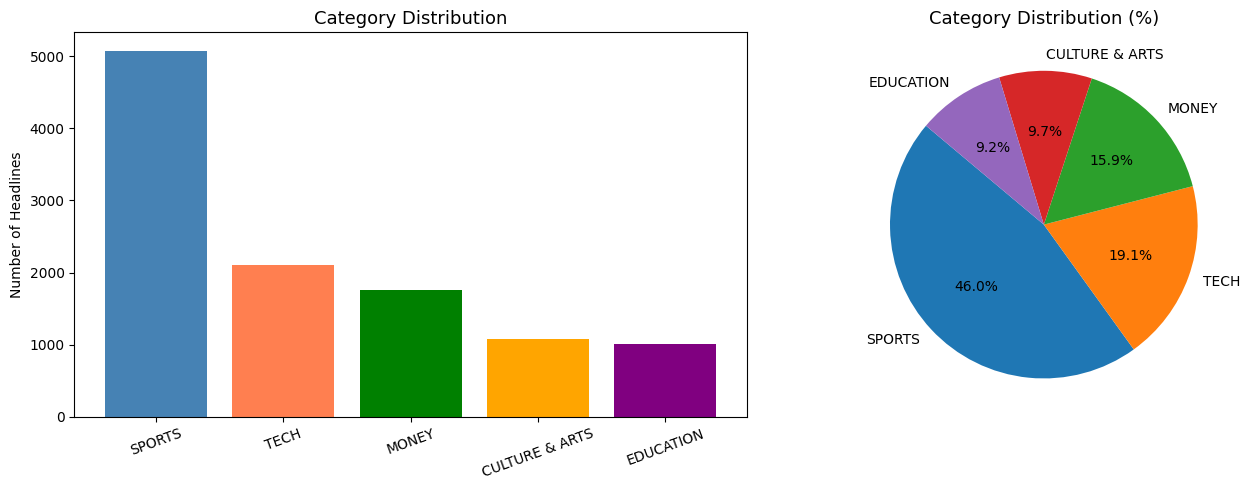

⚠️ Dataset is IMBALANCED — SPORTS dominates with 46.0 %


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['steelblue','coral','green','orange','purple'])
axes[0].set_title('Category Distribution', fontsize=13)
axes[0].set_ylabel('Number of Headlines')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Category Distribution (%)', fontsize=13)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150)
plt.show()

print("⚠️ Dataset is IMBALANCED — SPORTS dominates with",
      round(counts['SPORTS']/len(df)*100, 1), "%")

In [10]:
print("=== SAMPLE HEADLINES PER CATEGORY ===\n")
for cat in df['category'].unique():
    print(f"📌 {cat}:")
    samples = df[df['category']==cat]['headline'].head(3).tolist()
    for s in samples:
        print(f"   → {s}")
    print()

=== SAMPLE HEADLINES PER CATEGORY ===

📌 CULTURE & ARTS:
   → How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
   → 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
   → Meet Alex Aster, The TikToker Changing The Publishing Industry For The Better

📌 TECH:
   → Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
   → TikTok Search Results Riddled With Misinformation: Report
   → Citing Imminent Danger Cloudflare Drops Hate Site Kiwi Farms

📌 SPORTS:
   → Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
   → Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
   → Boston Marathon To Make Race More Inclusive For Nonbinary Runners

📌 EDUCATION:
   → Cyberattack Prompts Los Angeles School District To Shut Down Its Computer Systems
   → Minneapolis Teacher Contract Race Language Ignites Firestorm
   → Despite GOP Attacks, Parents Are Pretty Happy With Their Kids' Schools, Poll Finds

📌 MONEY:
   → Why You S

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 5. Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 6. Handle contractions
    contractions = {
        "don't":"do not", "can't":"cannot", "won't":"will not",
        "it's":"it is", "i'm":"i am", "you're":"you are",
        "he's":"he is", "she's":"she is", "they're":"they are",
        "we're":"we are", "that's":"that is", "what's":"what is",
        "isn't":"is not", "aren't":"are not", "wasn't":"was not",
        "weren't":"were not", "hasn't":"has not", "haven't":"have not"
    }
    for word, replacement in contractions.items():
        text = text.replace(word, replacement)

    # 7. Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)

print("✅ Cleaning function defined!")

✅ Cleaning function defined!


In [12]:
print("Cleaning headlines... please wait...")
df['cleaned'] = df['headline'].apply(clean_text)

print("✅ Done!")
print("\nOriginal  :", df['headline'].iloc[0])
print("Cleaned   :", df['cleaned'].iloc[0])

Cleaning headlines... please wait...
✅ Done!

Original  : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned   : new documentary capture complexity child immigrant


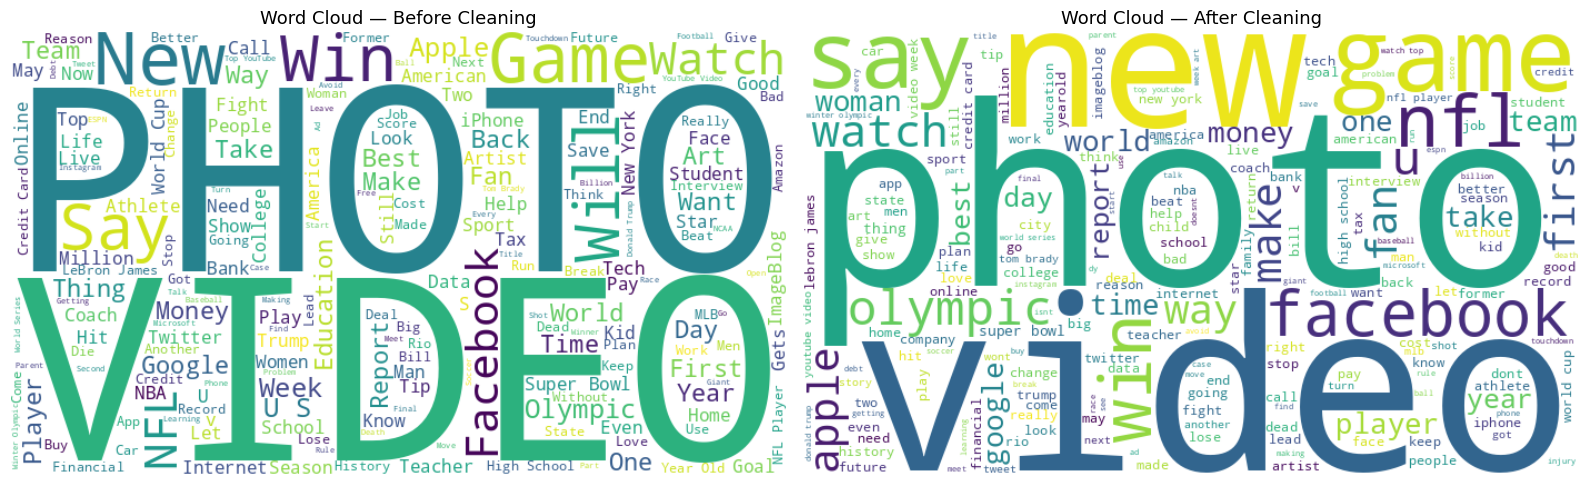

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before cleaning
all_text_before = ' '.join(df['headline'].tolist())
wc_before = WordCloud(width=700, height=400,
                       background_color='white').generate(all_text_before)
axes[0].imshow(wc_before, interpolation='bilinear')
axes[0].set_title('Word Cloud — Before Cleaning', fontsize=13)
axes[0].axis('off')

# After cleaning
all_text_after = ' '.join(df['cleaned'].tolist())
wc_after = WordCloud(width=700, height=400,
                      background_color='white',
                      colormap='viridis').generate(all_text_after)
axes[1].imshow(wc_after, interpolation='bilinear')
axes[1].set_title('Word Cloud — After Cleaning', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/wordclouds.png', dpi=150)
plt.show()

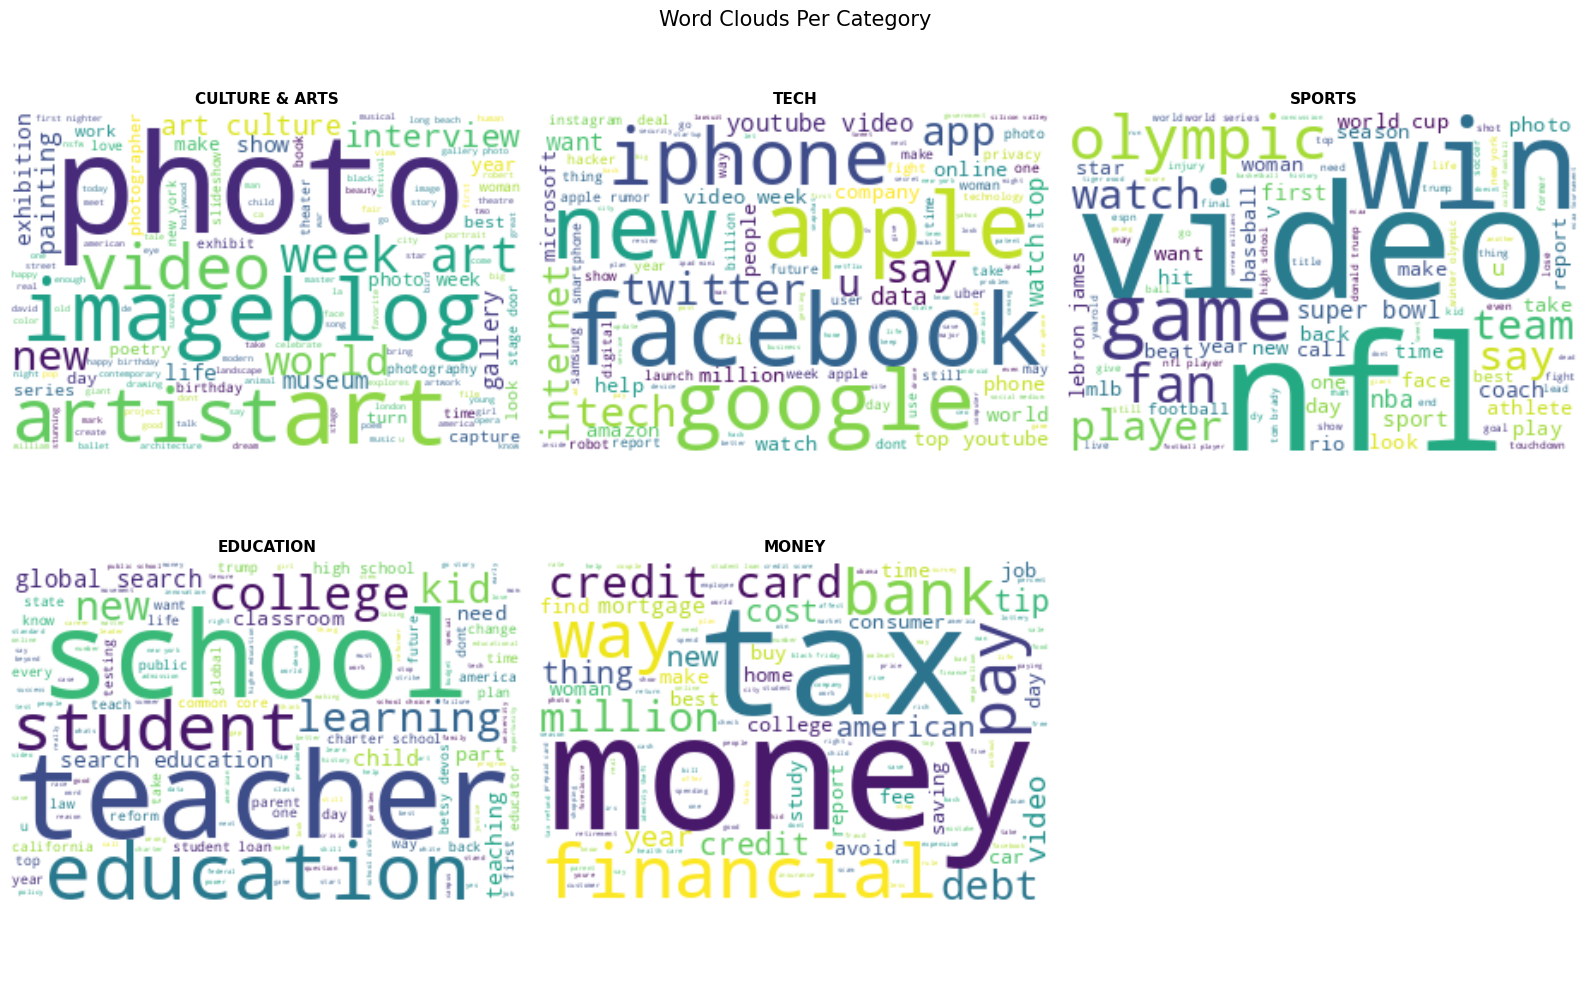

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
categories = df['category'].unique()

for ax, cat in zip(axes.flatten(), categories):
    text = ' '.join(df[df['category']==cat]['cleaned'].tolist())
    wc = WordCloud(width=300, height=200,
                   background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontsize=11, fontweight='bold')
    ax.axis('off')

# Hide last empty subplot if needed
for ax in axes.flatten()[len(categories):]:
    ax.axis('off')

plt.suptitle('Word Clouds Per Category', fontsize=15)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/category_wordclouds.png', dpi=150)
plt.show()

In [15]:
# Convert category names to numbers
# SPORTS=0, TECH=1, MONEY=2, etc.
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

CLASSES_NLP = list(le.classes_)
NUM_CLASSES  = len(CLASSES_NLP)
print(f"\nTotal classes: {NUM_CLASSES}")

Label mapping:
  CULTURE & ARTS → 0
  EDUCATION → 1
  MONEY → 2
  SPORTS → 3
  TECH → 4

Total classes: 5


In [16]:
X = df['cleaned'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,    # 80% train, 20% test
    random_state = 42,
    stratify     = y       # keep class balance in both splits
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 8820
Test samples     : 2205


In [17]:
VOCAB_SIZE = 10000   # keep top 10,000 most common words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
# oov_token handles words not seen during training

tokenizer.fit_on_texts(X_train)   # learn vocabulary from training data only

# Convert text to sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("Example original  :", X_train[0])
print("Example as numbers:", X_train_seq[0])
print("\nVocabulary size   :", len(tokenizer.word_index))

Example original  : here need know apple fbi showdown dc
Example as numbers: [75, 65, 67, 12, 375, 2143, 787]

Vocabulary size   : 12058


95th percentile length: 11
Using MAX_LEN = 11


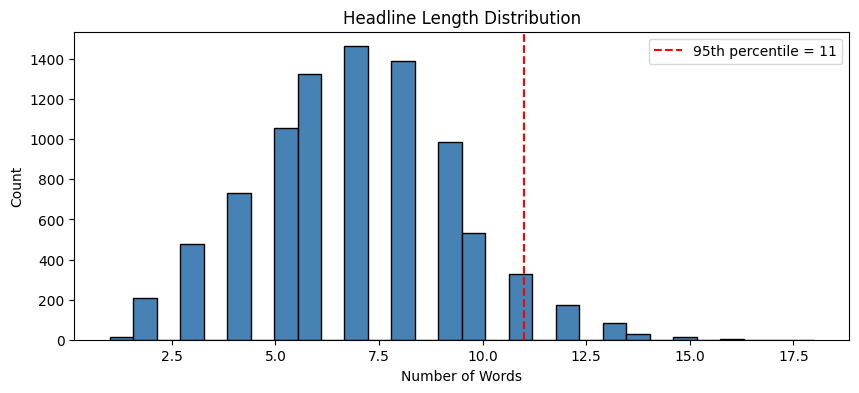


X_train_pad shape: (8820, 11)
X_test_pad shape : (2205, 11)


In [18]:
# Find good max length using 95th percentile
lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"95th percentile length: {MAX_LEN}")
print(f"Using MAX_LEN = {MAX_LEN}")

# Plot headline length distribution
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title('Headline Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.savefig(f'{SAVE_DIR}/length_distribution.png', dpi=150)
plt.show()

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape : {X_test_pad.shape}")

In [19]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

y_train_cat shape: (8820, 5)
y_test_cat shape : (2205, 5)


In [21]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, X_test, y_test, title):
    # Get predictions
    preds  = model.predict(X_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=CLASSES_NLP))

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_NLP)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} — Confusion Matrix')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{title.replace(" ","_")}_cm.png', dpi=150)
    plt.show()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5727 - loss: 1.0985 - val_accuracy: 0.7336 - val_loss: 0.7478
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8076 - loss: 0.5409 - val_accuracy: 0.7857 - val_loss: 0.6645
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9180 - loss: 0.2589 - val_accuracy: 0.8016 - val_loss: 0.6668
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9620 - loss: 0.1290 - val_accuracy: 0.7664 - val_loss: 0.8529
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9777 - loss: 0.0781 - val_accuracy: 0.7800 - val_loss: 0.8798
✅ Model 1 Training Time: 0.4 minutes


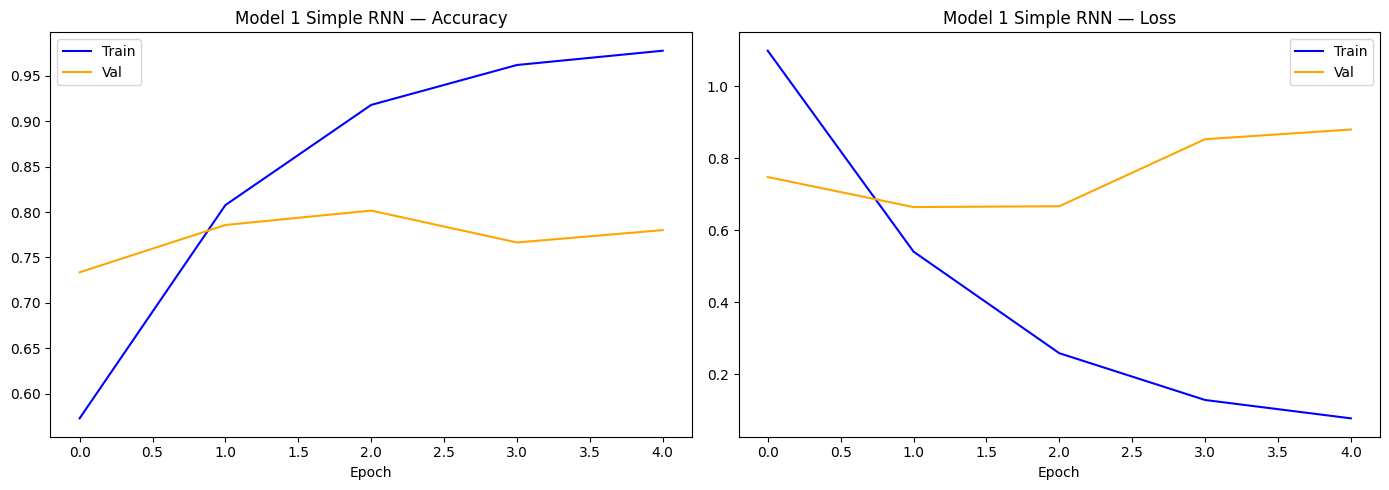


  Model 1 Simple RNN
                precision    recall  f1-score   support

CULTURE & ARTS       0.57      0.60      0.58       215
     EDUCATION       0.53      0.49      0.51       203
         MONEY       0.73      0.63      0.68       351
        SPORTS       0.89      0.92      0.91      1015
          TECH       0.74      0.77      0.75       421

      accuracy                           0.78      2205
     macro avg       0.69      0.68      0.69      2205
  weighted avg       0.77      0.78      0.77      2205



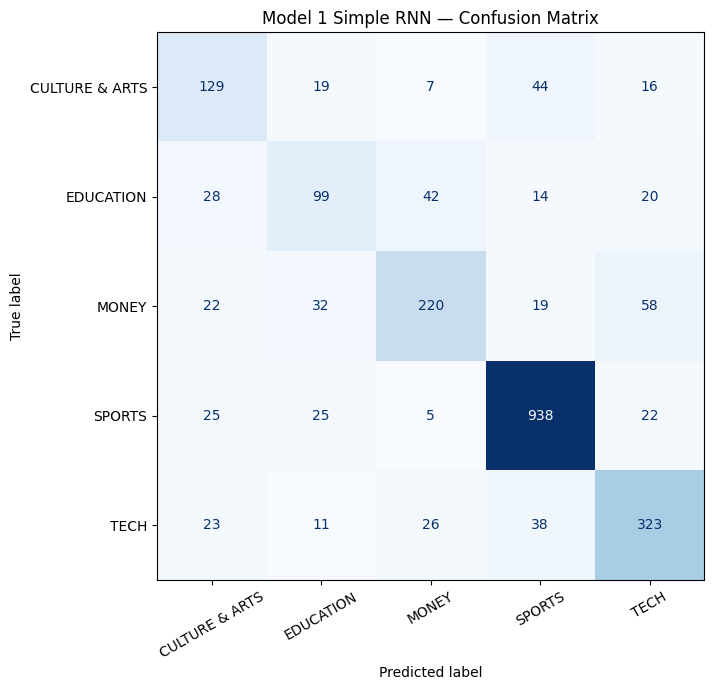

✅ Model 1 saved!


In [22]:
EMBED_DIM = 64   # size of word vectors

model1 = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN),
    layers.SimpleRNN(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='Simple_RNN')

model1.summary()

model1.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.1,
    epochs           = 20,
    batch_size       = 64,
    callbacks        = [es]
)
time1 = time.time() - start
print(f"✅ Model 1 Training Time: {time1/60:.1f} minutes")

plot_history(history1, 'Model 1 Simple RNN')
evaluate_model(model1, X_test_pad, y_test_cat, 'Model 1 Simple RNN')

# Save
model1.save(f'{SAVE_DIR}/model1_rnn.h5')
print("✅ Model 1 saved!")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.5351 - loss: 1.1414 - val_accuracy: 0.6066 - val_loss: 0.8893
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.6929 - loss: 0.7129 - val_accuracy: 0.7460 - val_loss: 0.6664
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8662 - loss: 0.3801 - val_accuracy: 0.8186 - val_loss: 0.5562
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9393 - loss: 0.1972 - val_accuracy: 0.8039 - val_loss: 0.6765
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9718 - loss: 0.1049 - val_accuracy: 0.8061 - val_loss: 0.8318
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9841 - loss: 0.0704 - val_accuracy: 0.7982 - val_loss: 0.8753
✅ Model 2 Training Time: 0.9 minutes


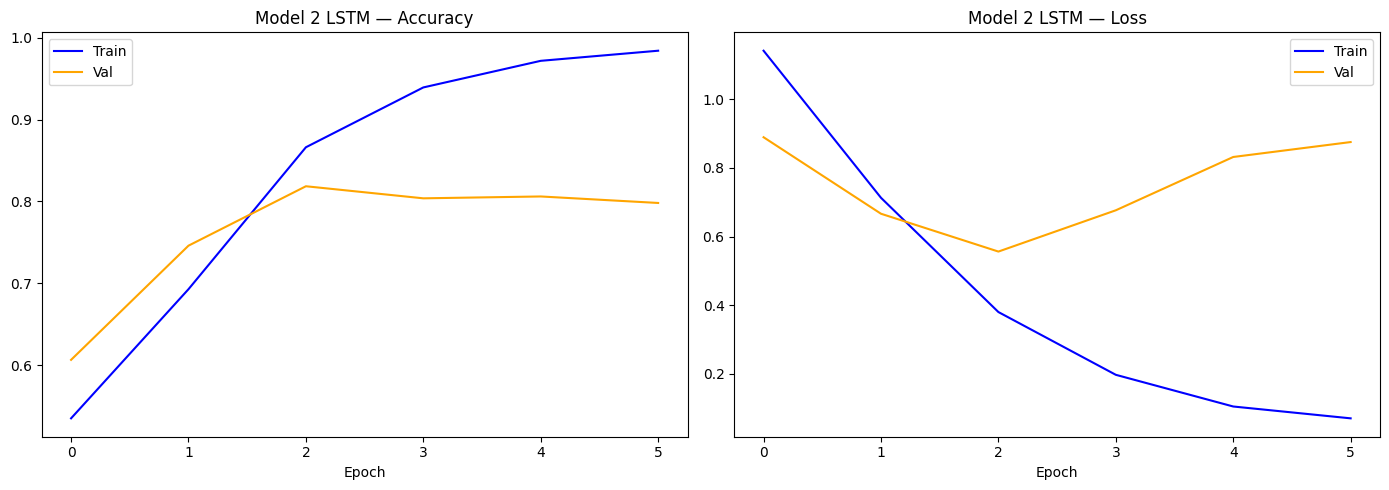


  Model 2 LSTM
                precision    recall  f1-score   support

CULTURE & ARTS       0.61      0.68      0.64       215
     EDUCATION       0.75      0.63      0.69       203
         MONEY       0.77      0.77      0.77       351
        SPORTS       0.91      0.94      0.93      1015
          TECH       0.79      0.73      0.76       421

      accuracy                           0.82      2205
     macro avg       0.77      0.75      0.76      2205
  weighted avg       0.82      0.82      0.82      2205



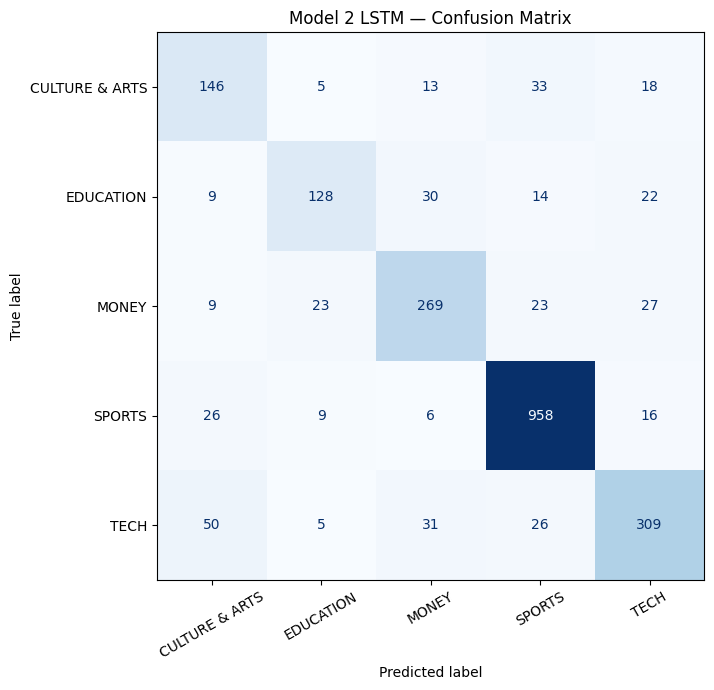

✅ Model 2 saved!


In [23]:
model2 = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Model')

model2.summary()

model2.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

start = time.time()
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.1,
    epochs           = 20,
    batch_size       = 64,
    callbacks        = [es]
)
time2 = time.time() - start
print(f"✅ Model 2 Training Time: {time2/60:.1f} minutes")

plot_history(history2, 'Model 2 LSTM')
evaluate_model(model2, X_test_pad, y_test_cat, 'Model 2 LSTM')

model2.save(f'{SAVE_DIR}/model2_lstm.h5')
print("✅ Model 2 saved!")

In [24]:
# Download GloVe pretrained embeddings (this takes a minute)
!pip install gensim --quiet
import gensim.downloader as api

print("Downloading GloVe embeddings... please wait...")
embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dimensional
print("✅ GloVe loaded!")
print("Vocabulary size:", len(embedding_model))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.3 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
✅ GloVe loaded!
Vocabulary size: 400000


In [25]:
GLOVE_DIM = 50   # must match downloaded model (gigaword-50)

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

found = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found += 1

print(f"Words found in GloVe: {found} / {min(VOCAB_SIZE, len(tokenizer.word_index))}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe: 9102 / 10000
Embedding matrix shape: (10000, 50)


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.7348 - loss: 0.7671 - val_accuracy: 0.8175 - val_loss: 0.5446
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8217 - loss: 0.5376 - val_accuracy: 0.8333 - val_loss: 0.4948
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.8338 - loss: 0.4990 - val_accuracy: 0.8265 - val_loss: 0.5248
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.8463 - loss: 0.4606 - val_accuracy: 0.8243 - val_loss: 0.4655
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8582 - loss: 0.4166 - val_accuracy: 0.8390 - val_loss: 0.4698
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8699 - loss: 0.3950 - val_accuracy: 0.8526 - val_loss: 0.4510
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8770 - loss: 0.3635 - val_accuracy: 0.8345 - val_loss: 0.4647
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8937 - loss: 0.3310 - val_ac

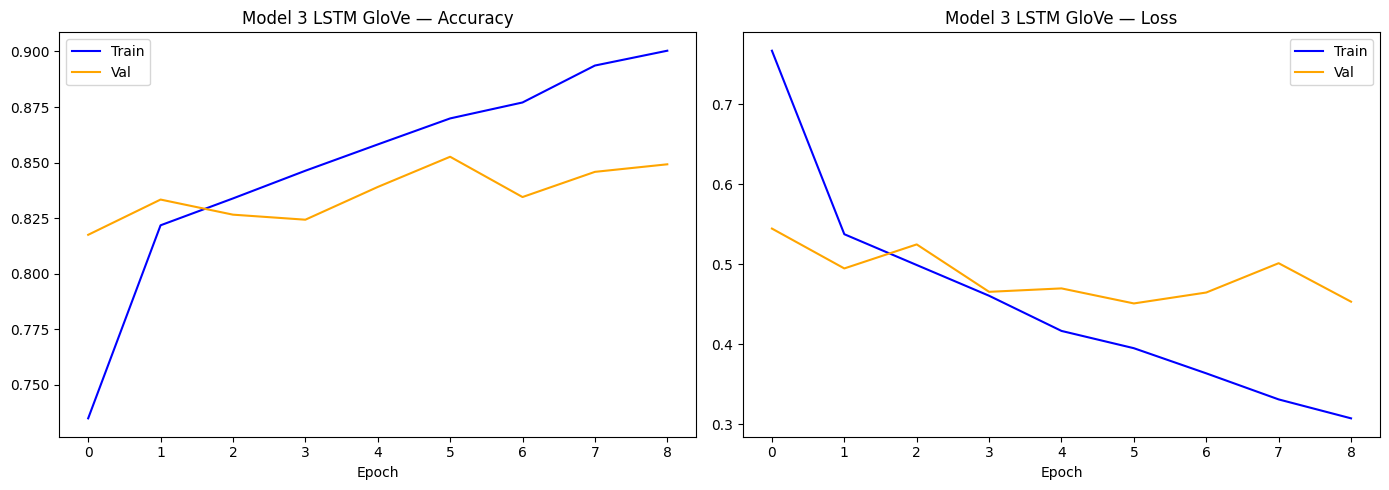


  Model 3 LSTM GloVe
                precision    recall  f1-score   support

CULTURE & ARTS       0.84      0.75      0.79       215
     EDUCATION       0.74      0.72      0.73       203
         MONEY       0.80      0.77      0.78       351
        SPORTS       0.89      0.94      0.92      1015
          TECH       0.82      0.80      0.81       421

      accuracy                           0.85      2205
     macro avg       0.82      0.80      0.81      2205
  weighted avg       0.85      0.85      0.85      2205



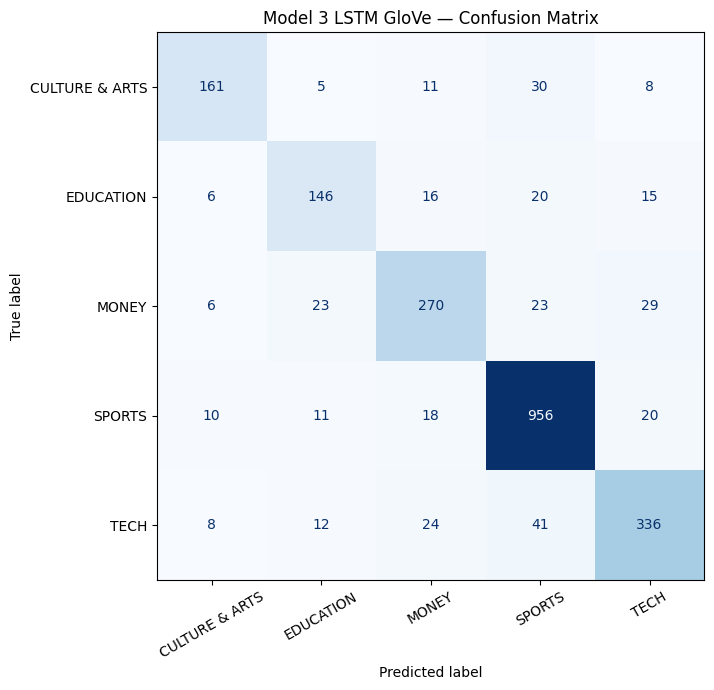

✅ Model 3 saved!


In [26]:
model3 = models.Sequential([
    layers.Embedding(
        input_dim    = VOCAB_SIZE,
        output_dim   = GLOVE_DIM,
        weights      = [embedding_matrix],   # use pretrained weights
        input_length = MAX_LEN,
        trainable    = False                 # freeze embeddings
    ),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe')

model3.summary()

model3.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

start = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.1,
    epochs           = 20,
    batch_size       = 64,
    callbacks        = [es]
)
time3 = time.time() - start
print(f"✅ Model 3 Training Time: {time3/60:.1f} minutes")

plot_history(history3, 'Model 3 LSTM GloVe')
evaluate_model(model3, X_test_pad, y_test_cat, 'Model 3 LSTM GloVe')

model3.save(f'{SAVE_DIR}/model3_lstm_glove.h5')
print("✅ Model 3 saved!")

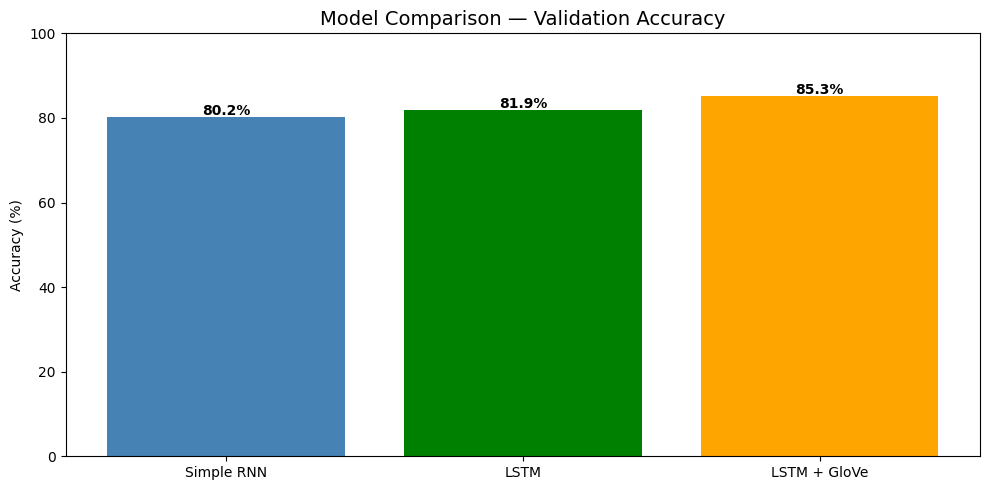


===== MODEL COMPARISON =====
  Simple RNN           → Accuracy: 80.2%  |  Time: 0.4 mins
  LSTM                 → Accuracy: 81.9%  |  Time: 0.9 mins
  LSTM + GloVe         → Accuracy: 85.3%  |  Time: 1.5 mins


In [27]:
# Collect results
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
histories   = [history1, history2, history3]
times       = [time1, time2, time3]

# Final validation accuracy
final_accs = [max(h.history['val_accuracy']) for h in histories]

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, [a*100 for a in final_accs],
               color=['steelblue','green','orange'])
plt.title('Model Comparison — Validation Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             acc*100 + 0.5, f'{acc*100:.1f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/model_comparison.png', dpi=150)
plt.show()

# Training time comparison
print("\n===== MODEL COMPARISON =====")
for name, acc, t in zip(model_names, final_accs, times):
    print(f"  {name:<20} → Accuracy: {acc*100:.1f}%  |  Time: {t/60:.1f} mins")

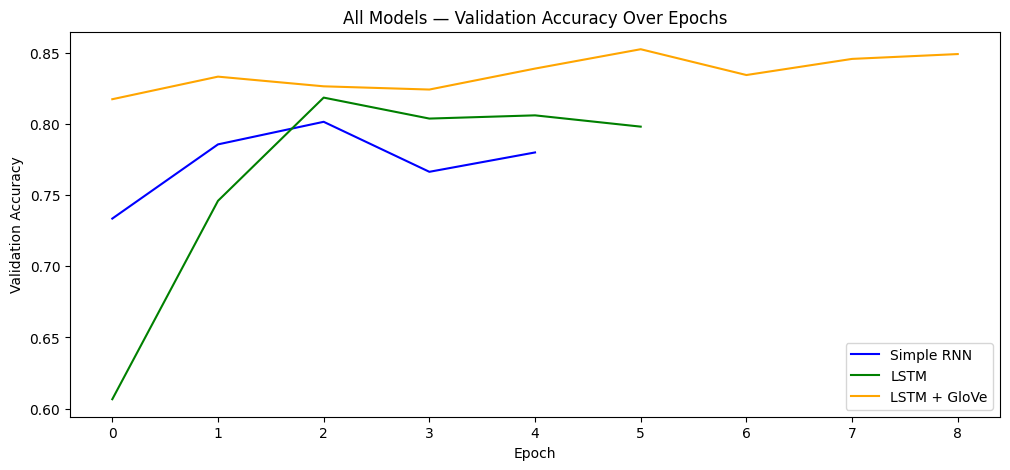

In [28]:
plt.figure(figsize=(12, 5))
colors = ['blue', 'green', 'orange']
for h, name, color in zip(histories, model_names, colors):
    plt.plot(h.history['val_accuracy'], label=name, color=color)
plt.title('All Models — Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.savefig(f'{SAVE_DIR}/all_models_comparison.png', dpi=150)
plt.show()

In [29]:
# Get predictions from best model (use model2 or model3)
preds  = model2.predict(X_test_pad, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Find wrong predictions
wrong_idx = np.where(y_pred != y_true)[0]

print(f"Total wrong predictions: {len(wrong_idx)} out of {len(y_true)}")
print(f"\n=== 5 WRONG PREDICTION EXAMPLES ===\n")

for i in wrong_idx[:5]:
    print(f"Headline  : {X_test[i]}")
    print(f"True Label: {CLASSES_NLP[y_true[i]]}")
    print(f"Predicted : {CLASSES_NLP[y_pred[i]]}")
    print(f"Confidence: {np.max(preds[i])*100:.1f}%")
    print("-" * 60)

Total wrong predictions: 395 out of 2205

=== 5 WRONG PREDICTION EXAMPLES ===

Headline  : judicial negligence compound political negligence south carolina
True Label: EDUCATION
Predicted : SPORTS
Confidence: 63.4%
------------------------------------------------------------
Headline  : literacy yes new literacy
True Label: EDUCATION
Predicted : MONEY
Confidence: 78.8%
------------------------------------------------------------
Headline  : go back grad school
True Label: MONEY
Predicted : EDUCATION
Confidence: 85.7%
------------------------------------------------------------
Headline  : robin ramirez amiko fountain marilyn johnson charged running million counterfeit coupon ring
True Label: MONEY
Predicted : SPORTS
Confidence: 86.9%
------------------------------------------------------------
Headline  : teach america houston tshirt sale
True Label: EDUCATION
Predicted : MONEY
Confidence: 87.8%
------------------------------------------------------------


In [30]:
!pip install gradio --quiet
import gradio as gr
from tensorflow.keras.models import load_model

# Load best model
best_model = model2  # or model3

def predict_category(headline):
    # Clean the input
    cleaned = clean_text(headline)
    # Tokenize and pad
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    # Predict
    pred    = best_model.predict(padded, verbose=0)
    probs   = {CLASSES_NLP[i]: float(pred[0][i]) for i in range(NUM_CLASSES)}
    return probs

# Launch GUI
demo = gr.Interface(
    fn          = predict_category,
    inputs      = gr.Textbox(label="Enter News Headline", placeholder="e.g. Scientists discover new planet..."),
    outputs     = gr.Label(label="Predicted Category"),
    title       = "📰 News Category Classifier",
    description = "Type a news headline and the model will predict its category."
)

demo.launch(share=True)  # share=True gives a public link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://786d6147deab889ee0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
